In [1]:
import numpy as np
import pandas as pd
import fastbox as fb
#fb.set_server(0) 
#connection via vpn is strongly recommanded

Fastbox: Loading configuration...
Fastbox: Default configuration saved to fastbox_config.pkl.
Fastbox: Configuration loaded successfully. Selected server: SJTU NODE1


In [2]:
fb.auth()

Please enter your user name and password for authentication.

Please input your user name:

 egrishin.25@saif.sjtu.edu.cn


Please input your password:

 ········


Fastbox: Configuration saved to fastbox_config.pkl.


User authorized.

## Checking Dataset

We first inspect the stock master table obtained from `fb.data.stocks.info()`.

- Each row corresponds to a **single stock**, indexed by `instrumentid`.
- The dataset contains **firm-level metadata**, including:
  - `exchange` (listing exchange)
  - `industry` (industry classification)
  - `area` (region)
  - `market` (Main Board, ChiNext, etc.)
  - listing and delisting dates

The `instrumentid` is used as the **unique identifier** and serves as the key for merging with daily stock data.


In [3]:
df = fb.data.stocks.info()

In [4]:
df.columns

Index(['exchange', 'name', 'area', 'industry', 'fullname', 'enname', 'cnspell',
       'market', 'curr_type', 'list_status', 'list_date', 'delist_date',
       'is_hs'],
      dtype='object')

In [5]:
df.head(2)

,exchange,name,area,industry,fullname,enname,cnspell,market,curr_type,list_status,list_date,delist_date,is_hs
instrumentid,,,,,,,,,,,,,
300330,SZSE,计通退(退),None,None,上海华虹计通智能系统股份有限公司,"Shanghai Huahong Jitong Smart System Co.,Ltd.",jtt,创业板,CNY,D,2012-06-19 09:30:00+08:00,2023-05-24 15:30:00+08:00,N
300336,SZSE,新文退(退),None,None,上海新文化传媒集团股份有限公司,"Shanghai New Culture Media Group Co., Ltd.",xwt,创业板,CNY,D,2012-07-10 09:30:00+08:00,2023-07-05 15:30:00+08:00,N


# **QUESTION 1: Stock Clustering and Pairs Trading**

# **1. Data Preparation**

In [6]:
# Reproducibility
RANDOM_SEED = 42

# Randomly select 104 stocks (some are not in 2025)
df_100 = df.sample(n=104, random_state=RANDOM_SEED)

# Check result
print(df_100.shape)
df_100.head(2)

(104, 13)


,exchange,name,area,industry,fullname,enname,cnspell,market,curr_type,list_status,list_date,delist_date,is_hs
instrumentid,,,,,,,,,,,,,
836208,BSE,青矩技术,北京,建筑工程,青矩技术股份有限公司,"Greetec Co.,Ltd.",qjjs,北交所,CNY,L,2023-06-29 09:30:00+08:00,NaT,N
600461,SSE,洪城环境,江西,水务,江西洪城环境股份有限公司,"Jiangxi Hongcheng Environment Co.,Ltd.",hchj,主板,CNY,L,2004-06-01 09:30:00+08:00,NaT,H


In [7]:
instrument_ids = df_100.index.tolist()

len(instrument_ids)  # should be 104

104

In [8]:
df_index = fb.data.stocks.daily(
    instrumentid=instrument_ids,
    complete=True,
    from_date="2025-01-01",
    to_date="2026-12-31"
)

In [9]:
df_index.tail()

close   open   high    low       vol      amount  \
date       instrumentid                                                     
2025-12-31 920547        23.65  23.71  23.93  23.55   5265.26   12462.812   
           920593        36.52  37.91  37.99  36.40  50042.81  184781.144   
           920706        25.00  25.46  25.74  24.69  29163.24   73197.303   
           920719        12.90  12.86  13.27  12.77  32180.31   41937.996   
           920961        28.36  27.67  28.66  27.60  69942.55  196593.891   

                         name zhengzhouid  
date       instrumentid                    
2025-12-31 920547        无锡晶海  920547.BSE  
           920593        鼎智科技  920593.BSE  
           920706        铁拓机械  920706.BSE  
           920719        宁新新材  920719.BSE  
           920961        创远信科  920961.BSE

In [35]:
df_index.reset_index()["instrumentid"].nunique() # should be 100

100

In [36]:
instrument_list = df_index.reset_index()["instrumentid"].unique().tolist()
len(instrument_list)   # should be 100 (or your actual number)
instrument_list

['000088',
 '000509',
 '000558',
 '000593',
 '000665',
 '000678',
 '000713',
 '000858',
 '000913',
 '000966',
 '002016',
 '002032',
 '002056',
 '002069',
 '002156',
 '002211',
 '002323',
 '002360',
 '002403',
 '002470',
 '002513',
 '002520',
 '002556',
 '002584',
 '002718',
 '002746',
 '002761',
 '002782',
 '002827',
 '002977',
 '003022',
 '300001',
 '300059',
 '300118',
 '300239',
 '300251',
 '300307',
 '300327',
 '300381',
 '300512',
 '300572',
 '300576',
 '300620',
 '300808',
 '300928',
 '301207',
 '600202',
 '600363',
 '600367',
 '600420',
 '600461',
 '600531',
 '600533',
 '600536',
 '600572',
 '600641',
 '600751',
 '600792',
 '601568',
 '603075',
 '603082',
 '603181',
 '603389',
 '603501',
 '603727',
 '603755',
 '603878',
 '605123',
 '605258',
 '688035',
 '688046',
 '688050',
 '688051',
 '688057',
 '688092',
 '688100',
 '688116',
 '688150',
 '688283',
 '688314',
 '688328',
 '688733',
 '688739',
 '832469',
 '835438',
 '836208',
 '870726',
 '871478',
 '871642',
 '873223',
 '920304',

## Objective
For each stock $i$, we construct a feature vector $X_i$ using **daily technical features averaged over the last six months**.  
These vectors form the input for **PCA and clustering** in the next stage.

## Stock Universe
- 100 stocks are randomly selected from the FastBox API.
- Daily data are collected for the period $[2025\text{-}01\text{-}01,\; 2025\text{-}12\text{-}31]$.
- Only stocks with available data during 2025 are retained.
- The **last six months** of observations are used for feature construction.

## Daily Features
The following numeric daily features provided by FastBox are used:

| Feature | Description |
|------|-------------|
| `close` | Daily closing price |
| `open` | Daily opening price |
| `high` | Daily highest price |
| `low` | Daily lowest price |
| `vol` | Trading volume |
| `amount` | Trading turnover |

Identifier and text fields (e.g. `date`, `instrumentid`, `name`) are excluded.

## Feature Vector Construction

For each stock $i$, the feature vector is defined as:

$$
X_i =
\begin{bmatrix}
\overline{close}_i \\
\overline{open}_i \\
\overline{high}_i \\
\overline{low}_i \\
\overline{vol}_i \\
\overline{amount}_i
\end{bmatrix}
$$

Each component is the time average of the corresponding daily feature over the six-month window.

Formally, for a generic daily feature $f$:

$$
\overline{f}_i = \frac{1}{T} \sum_{t=1}^{T} f_{i,t}
$$

where:
- $f_{i,t}$ denotes the value of feature $f$ for stock $i$ on day $t$
- $T$ is the number of trading days in the last six months

## Feature Matrix
Stacking all feature vectors yields the feature matrix:

$$
X =
\begin{bmatrix}
X_1^\top \\
X_2^\top \\
\vdots \\
X_N^\top
\end{bmatrix}
\in \mathbb{R}^{N \times 6}
$$

where $N$ is the number of stocks (approximately $100$).

In [15]:
df0 = df_index.copy()

# Move index into columns
df0 = df0.reset_index()

# Identify the date column created by reset_index()
reset_cols = [c for c in df0.columns if c not in df_index.columns]  # new columns created from index
print("Index columns after reset_index():", reset_cols)

# Choose date column
date_col = "date" if "date" in df0.columns else reset_cols[0]

# Convert date column to datetime
df0[date_col] = pd.to_datetime(df0[date_col], errors="coerce")

# Filter last 6 months
end_date = df0[date_col].max()
start_date = end_date - pd.DateOffset(months=6)
df_6m = df0[df0[date_col].between(start_date, end_date)].copy()

print("6M window:", df_6m[date_col].min(), "→", df_6m[date_col].max())
print("df_6m shape:", df_6m.shape)
print("Has instrumentid column?", "instrumentid" in df_6m.columns)

Index columns after reset_index(): ['date', 'instrumentid']
6M window: 2025-06-30 00:00:00 → 2025-12-31 00:00:00
df_6m shape: (12077, 10)
Has instrumentid column? True


## Feature Scaling
Before applying PCA, each feature is standardized to ensure comparability:

$$
\tilde{X}_{i,j} = \frac{X_{i,j} - \mu_j}{\sigma_j}
$$

where:
- $\mu_j$ is the cross-sectional mean of feature $j$
- $\sigma_j$ is the corresponding standard deviation

## Exploratory Analysis
- Feature distributions reveal heterogeneity across stocks.
- Strong correlations among price-related features motivate dimensionality reduction via PCA.

In [17]:
# Select numeric daily features (exclude IDs/text)
exclude = {"date", "instrumentid", "name", "zhengzhouid"}
feature_cols = [c for c in df_6m.columns if c not in exclude and pd.api.types.is_numeric_dtype(df_6m[c])]

print("Feature columns:", feature_cols)

# Average of daily features over last 6 months
X = df_6m.groupby("instrumentid")[feature_cols].mean()

# Clean for PCA
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

print("Feature matrix X shape:", X.shape)
X

Feature columns: ['close', 'open', 'high', 'low', 'vol', 'amount']
Feature matrix X shape: (100, 6)


,close,open,high,low,vol,amount
instrumentid,,,,,,
000088,4.462908,4.461490,4.486005,4.435686,2.828774e+05,126470.368890
000509,3.491969,3.493701,3.559055,3.429764,3.027931e+05,108590.441882
000558,5.639606,5.616535,5.774331,5.501969,1.219985e+06,731855.820520
000593,8.190080,8.161040,8.385680,7.977440,2.072918e+05,200688.895808
000665,5.874331,5.863622,5.988898,5.768898,5.558445e+05,335773.139827
...,...,...,...,...,...,...
920547,26.169764,26.240787,26.703228,25.761024,1.524707e+04,41446.124685
920593,37.109606,37.126457,38.018504,36.444724,4.844856e+04,187710.895276
920706,25.004961,24.894803,25.957165,24.269291,5.693445e+04,151443.265480


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    index=X.index,
    columns=X.columns
)

X_scaled.head()

,close,open,high,low,vol,amount
instrumentid,,,,,,
000088,-0.872862,-0.873555,-0.876763,-0.869630,0.120910,-0.261369
000509,-0.916330,-0.916983,-0.917505,-0.915465,0.164264,-0.276785
000558,-0.820183,-0.821723,-0.820137,-0.821045,2.160858,0.260602
000593,-0.706002,-0.707542,-0.705361,-0.708250,-0.043629,-0.197377
000665,-0.809675,-0.810636,-0.810706,-0.808882,0.715120,-0.080905


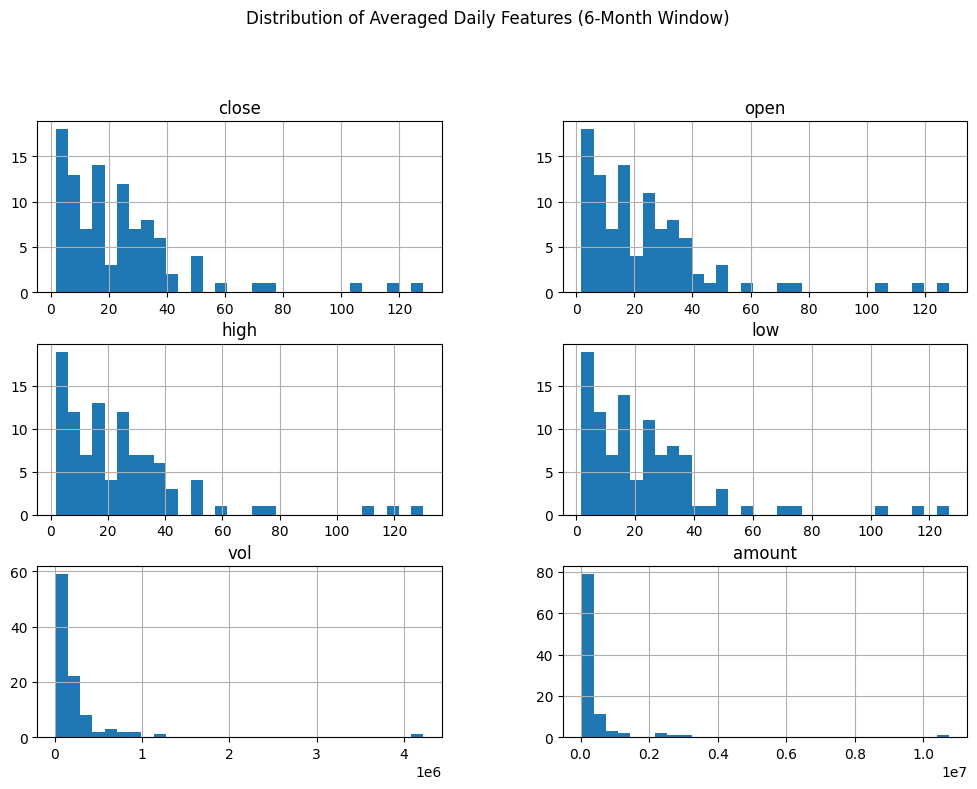

In [20]:
import matplotlib.pyplot as plt

X.hist(bins=30, figsize=(12, 8))
plt.suptitle("Distribution of Averaged Daily Features (6-Month Window)", y=1.02)
plt.show()


### Price-Based Features
The distributions of `close`, `open`, `high`, and `low` exhibit the following properties:

- Strong **right-skewness**
- Presence of **outliers** corresponding to high-priced stocks
- High similarity across price features, indicating **multicollinearity**

This suggests that raw price levels contain overlapping information and are not directly suitable for distance-based clustering without transformation.

### Liquidity Features
The liquidity-related variables (`vol`, `amount`) display:

- Extremely **heavy-tailed distributions**
- Large dispersion across stocks
- Orders-of-magnitude differences between low- and high-liquidity stocks

These characteristics imply that liquidity variables dominate scale-sensitive methods unless properly normalized.

### Implications for Methodology
The observed distributional properties motivate two key preprocessing steps:

1. **Feature standardization**, to ensure comparability across dimensions  
2. **Principal Component Analysis (PCA)**, to:
   - Reduce dimensionality
   - Mitigate multicollinearity
   - Extract dominant latent factors driving cross-sectional variation

# **2. Dimensionality Reduction**

The variance explained by each principal component is:

$$
[0.684,\; 0.307,\; 0.008,\; \approx 0,\; \approx 0,\; \approx 0]
$$

This indicates that:
- **PC1 alone explains about 68.4%** of the total variance
- **PC2 explains an additional 30.7%**
- Remaining components contribute **negligible variance**

The cumulative explained variance is:

$$
[0.684,\; 0.991,\; 0.999,\; 1.000]
$$

Thus:
- The **first two principal components explain approximately 99.1%** of the total variance
- The 80% variance threshold is exceeded with **$k = 2$ components**

In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

In [22]:
k = np.argmax(cumulative_var >= 0.80) + 1

print("Explained variance by component:", explained_var)
print("Cumulative explained variance:", cumulative_var)
print("Selected number of components k:", k)

Explained variance by component: [6.83926958e-01 3.07423433e-01 8.58400097e-03 6.43105763e-05
 9.94605722e-07 3.02633969e-07]
Cumulative explained variance: [0.68392696 0.99135039 0.99993439 0.9999987  0.9999997  1.        ]
Selected number of components k: 2


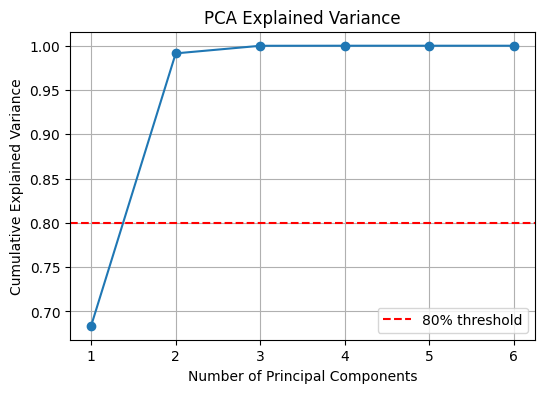

In [24]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker="o")
plt.axhline(0.80, color="red", linestyle="--", label="80% threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.grid(True)
plt.show()


## Interpretation of the PCA Structure
- **PC1** captures the dominant common movement across price and liquidity features, reflecting overall stock scale and activity.
- **PC2** captures secondary variation, likely related to relative differences between price level and trading activity.
- Higher-order components contain minimal information and are treated as noise.

## Projection into PCA Space
Each stock is projected into a two-dimensional PCA space:

$$
Z_i = (PC_{i,1},\; PC_{i,2})
$$

where:
- $Z_i \in \mathbb{R}^2$
- $PC_{i,1}$ and $PC_{i,2}$ represent the dominant latent factors governing stock similarity

In [25]:
pca = PCA(n_components=k)

Z = pd.DataFrame(
    pca.fit_transform(X_scaled),
    index=X.index,
    columns=[f"PC{i+1}" for i in range(k)]
)

Z.head()

,PC1,PC2
instrumentid,,
000088,-1.768570,0.069049
000509,-1.858078,0.097913
000558,-1.646545,1.895555
000593,-1.424353,-0.037102
000665,-1.633759,0.611705


In [26]:
print("Original feature space:", X.shape)
print("Reduced PCA space:", Z.shape)

Original feature space: (100, 6)
Reduced PCA space: (100, 2)


# **3. Peer Grouping**

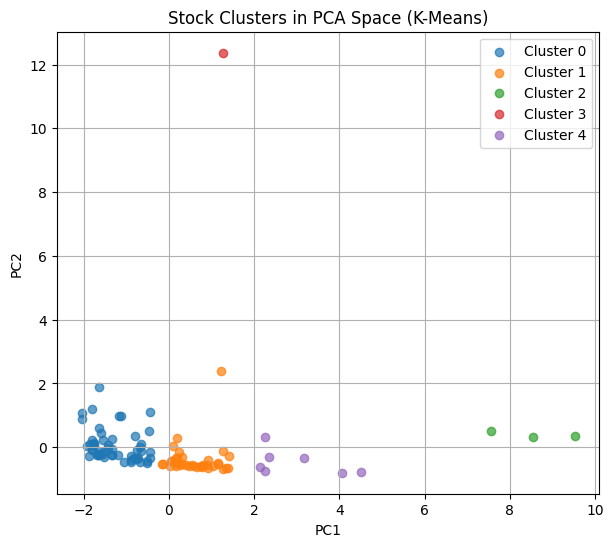

cluster
0    54
1    35
4     7
2     3
3     1
Name: count, dtype: int64

In [27]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

n_clusters = 5

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
labels = kmeans.fit_predict(Z)

# Attach cluster labels
Z_clustered = Z.copy()
Z_clustered["cluster"] = labels

# Visualize clusters in PCA space
plt.figure(figsize=(7, 6))
for c in range(n_clusters):
    subset = Z_clustered[Z_clustered["cluster"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {c}", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Stock Clusters in PCA Space (K-Means)")
plt.legend()
plt.grid(True)
plt.show()

# Quick sanity check
Z_clustered["cluster"].value_counts()

After PCA, each stock $i$ is represented in a low-dimensional space by:
$$
Z_i = (PC_{i,1}, PC_{i,2}) \in \mathbb{R}^2
$$
Stacking all stocks yields the PCA matrix:
$$
Z =
\begin{bmatrix}
Z_1^\top \\
Z_2^\top \\
\vdots \\
Z_N^\top
\end{bmatrix}
\in \mathbb{R}^{N \times 2}
$$
This matrix is the input for clustering.

Given a chosen number of clusters $K$, K-Means solves:

$$
\min_{\{C_k\}_{k=1}^K} \sum_{k=1}^K \sum_{i \in C_k}
\| Z_i - \mu_k \|_2^2
$$
where:
- $C_k$ is the set of stocks assigned to cluster $k$
- $\mu_k$ is the centroid of cluster $k$:

$$
\mu_k = \frac{1}{|C_k|} \sum_{i \in C_k} Z_i
$$
Each stock is assigned to the nearest centroid:
$$
\text{cluster}(i) = \arg\min_k \| Z_i - \mu_k \|_2
$$
Because PCA produces **orthogonal components**, the Euclidean distance used in K-Means is well-defined:
$$
\| Z_i - Z_j \|_2 =
\sqrt{(PC_{i,1}-PC_{j,1})^2 + (PC_{i,2}-PC_{j,2})^2}
$$

Thus, stocks close to each other in PCA space share similar dominant technical characteristics.

Let $\mathcal{C}_k$ denote cluster $k$

- Large clusters ($|\mathcal{C}_k|$ high) correspond to **typical stocks** with similar scale and liquidity.
- Small clusters correspond to **extreme values** of $(PC_1, PC_2)$ and act as outliers.

The separation is primarily driven by $PC_1$, which captures the dominant variance component:
$$
\text{Var}(PC_1) \gg \text{Var}(PC_2)
$$

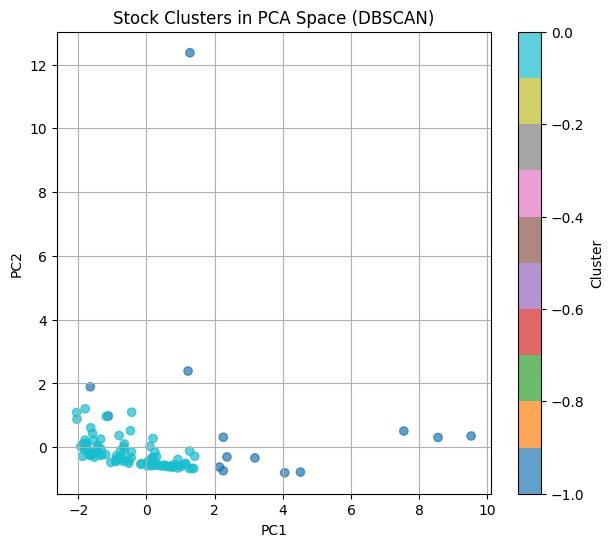

cluster
 0    86
-1    14
Name: count, dtype: int64

In [28]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# DBSCAN is sensitive to scale — PCA outputs are already standardized
dbscan = DBSCAN(eps=0.6, min_samples=4)
labels_db = dbscan.fit_predict(Z)

Z_db = Z.copy()
Z_db["cluster"] = labels_db  # -1 indicates noise

plt.figure(figsize=(7, 6))
scatter = plt.scatter(Z_db["PC1"], Z_db["PC2"], c=Z_db["cluster"], cmap="tab10", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Stock Clusters in PCA Space (DBSCAN)")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

Z_db["cluster"].value_counts()


DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups points based on **local density**, rather than distance to centroids.

It is defined by two parameters:
- $\varepsilon$ (epsilon): neighborhood radius
- $m$ (`min_samples`): minimum number of points required to form a dense region

For any stock $i$, define its $\varepsilon$-neighborhood as:

$$
\mathcal{N}_{\varepsilon}(Z_i)
=
\{ Z_j \in Z \mid \| Z_i - Z_j \|_2 \le \varepsilon \}
$$
where $\|\cdot\|_2$ is the Euclidean distance in PCA space.

Each stock is classified as one of the following:

A stock $i$ is a **core point** if:
$$
|\mathcal{N}_{\varepsilon}(Z_i)| \ge m
$$
Core points lie in regions of high density.

A stock $i$ is a **border point** if:
$$
|\mathcal{N}_{\varepsilon}(Z_i)| < m
\quad \text{and} \quad
\exists \; j \text{ core point such that } Z_i \in \mathcal{N}_{\varepsilon}(Z_j)
$$
Border points lie on the edge of clusters.

A stock $i$ is labeled as **noise** if it is neither a core nor a border point:
$$
\text{label}(i) = -1
$$
These points correspond to isolated or extreme observations.

Two stocks $i$ and $j$ belong to the same cluster if they are **density-connected**, i.e., there exists a sequence of stocks:
$$
Z_i \rightarrow Z_{k_1} \rightarrow \dots \rightarrow Z_j
$$
such that each consecutive pair lies within an $\varepsilon$-neighborhood of a core point.

**Comparison with K-Means**

| Aspect | K-Means | DBSCAN |
|-----|--------|--------|
| Cluster shape | Spherical | Arbitrary |
| Number of clusters | Fixed ($K$) | Data-driven |
| Outlier handling | No | Yes |
| Objective function | Variance minimization | Density connectivity |

DBSCAN explicitly identifies and isolates outliers, which is valuable for risk-aware pair selection.


**Why Clustering on PCA Components Instead of Raw Features?**

**(a) Multicollinearity in Raw Features**

Original features satisfy:
$$
\text{Cov}(X_j, X_k) \neq 0 \quad \text{for many } j \neq k
$$

This distorts distance-based clustering.

PCA enforces:

$$
\text{Cov}(PC_j, PC_k) = 0 \quad \forall j \neq k
$$

**(b) Dimensionality Reduction**

Raw feature space:
$$
X_i \in \mathbb{R}^6
$$
PCA-reduced space:
$$
Z_i \in \mathbb{R}^2
$$
with variance preservation:
$$
\frac{\sum_{j=1}^2 \lambda_j}{\sum_{j=1}^6 \lambda_j} \ge 0.80
$$

**(c) Noise Filtering**

Low-variance components satisfy:
$$
\lambda_j \approx 0 \quad \text{for } j > 2
$$
Removing them improves cluster stability.

**(d) Meaningful Distance Metric**

In PCA space, Euclidean distance approximates similarity in dominant latent factors:
$$
\| Z_i - Z_j \|_2 \approx \text{difference in systematic behavior}
$$

**Conclusion**

Clustering in PCA space provides a mathematically well-founded method for identifying peer groups.  
By minimizing within-cluster variance in an orthogonal, noise-reduced space, the approach yields economically meaningful stock groupings suitable for subsequent pairs trading analysis.


# **Part 2: Pair Identification**

Peer groups are obtained from **K-Means clustering in PCA space**.

- Each stock $i$ has a cluster label:
  
  $$
  \text{cluster}(i) \in \{0, 1, \dots, K-1\}
  $$

- The clustering output matrix has shape:

  $$
  Z_{\text{clustered}} \in \mathbb{R}^{100 \times 3}
  $$

  where columns correspond to $(PC1, PC2, \text{cluster})$.

- All **100 sampled stocks** are retained for pair identification.

In [29]:
# Z_clustered comes from K-Means
# index = instrumentid
# column = cluster
Z_clustered.head()

,PC1,PC2,cluster
instrumentid,,,
000088,-1.768570,0.069049,0
000509,-1.858078,0.097913,0
000558,-1.646545,1.895555,0
000593,-1.424353,-0.037102,0
000665,-1.633759,0.611705,0


In [41]:
Z_clustered.shape

(100, 3)

In [39]:
df_daily = df_index.reset_index().copy()
df_daily["date"] = pd.to_datetime(df_daily["date"])
df_daily = df_daily.sort_values(["instrumentid", "date"])

# Daily log returns (robust)
df_daily["ret"] = np.log(df_daily["close"]).groupby(df_daily["instrumentid"]).diff()

# Check
print(df_daily.columns)
df_daily[["date", "instrumentid", "close", "ret"]].head(10)

Index(['date', 'instrumentid', 'close', 'open', 'high', 'low', 'vol', 'amount',
       'name', 'zhengzhouid', 'ret'],
      dtype='object')


,date,instrumentid,close,ret
0,2025-01-02,000088,4.496579,NaN
96,2025-01-03,000088,4.429893,-0.014942
192,2025-01-06,000088,4.477526,0.010695
288,2025-01-07,000088,4.439419,-0.008547
384,2025-01-08,000088,4.429893,-0.002148
480,2025-01-09,000088,4.382260,-0.010811
576,2025-01-10,000088,4.363206,-0.004357
672,2025-01-13,000088,4.372733,0.002181
768,2025-01-14,000088,4.467999,0.021553
864,2025-01-15,000088,4.496579,0.006376


In [47]:
df_daily["cluster"] = df_daily["instrumentid"].map(Z_clustered["cluster"])
df_daily = df_daily.dropna(subset=["cluster"])

Let $\mathcal{C}_k$ denote the set of stocks in cluster $k$.

For each cluster:
1. Construct the return matrix:

$$
R_k = \big[ r_{i,t} \big]_{t,i \in \mathcal{C}_k}
$$

2. Compute the **pairwise correlation matrix**:

$$
\rho_{ij} = \text{Corr}(r_i, r_j), \quad i \neq j
$$

3. Extract the upper-triangular correlations and select the strongest pair:

$$
(i, j)_k = \arg\max_{i \neq j,\, i,j \in \mathcal{C}_k} \rho_{ij}
$$
Across all clusters, the final selected pair is defined as:
$$
(A, B) = \arg\max_k \; \rho_{(i, j)_k}
$$

In [32]:
best_pair = {
    "cluster": None,
    "stock_A": None,
    "stock_B": None,
    "correlation": -1
}

for c in sorted(df_daily["cluster"].unique()):
    cluster_data = df_daily[df_daily["cluster"] == c]

    ret_matrix = cluster_data.pivot(
        index="date",
        columns="instrumentid",
        values="ret"
    )

    ret_matrix = ret_matrix.dropna(how="all")
    ret_matrix = ret_matrix.dropna(axis=1, thresh=0.8 * len(ret_matrix))

    if ret_matrix.shape[1] < 2:
        continue

    corr = ret_matrix.corr()
    corr.index.name = "Stock_A"
    corr.columns.name = "Stock_B"

    corr_values = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            .stack()
            .reset_index(name="corr")
    )

    top = corr_values.loc[corr_values["corr"].idxmax()]

    if top["corr"] > best_pair["correlation"]:
        best_pair = {
            "cluster": c,
            "stock_A": top["Stock_A"],
            "stock_B": top["Stock_B"],
            "correlation": float(top["corr"]),
        }

best_pair

{'cluster': 1,
 'stock_A': '300928',
 'stock_B': '688092',
 'correlation': 0.8078980468926868}

In [48]:
n_unique_daily = df_daily["instrumentid"].nunique()
n_unique_daily

100

To visually confirm co-movement, price series are normalized to start at 1.0:

$$
\tilde{P}_{i,t} = \frac{P_{i,t}}{P_{i,0}}
$$

The normalized price paths of stocks `300928` and `688092` display strong alignment over time, consistent with the high return correlation.


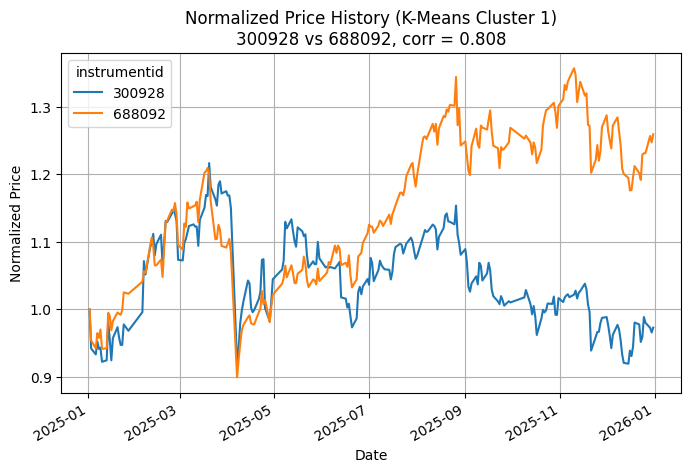

In [38]:
A, B = best_pair["stock_A"], best_pair["stock_B"]

price_pair = (
    df_daily[df_daily["instrumentid"].isin([A, B])]
    .pivot(index="date", columns="instrumentid", values="close")
    .dropna()
)

price_norm = price_pair / price_pair.iloc[0]

price_norm.plot(figsize=(8, 5))
plt.title(
    f"Normalized Price History (K-Means Cluster {best_pair['cluster']})\n"
    f"{A} vs {B}, corr = {best_pair['correlation']:.3f}"
)
plt.ylabel("Normalized Price")
plt.xlabel("Date")
plt.grid(True)
plt.show()

# **Part 3: Spread Modeling with EM Algorithm (GMM)**

# **1. Spread Calculation**

The objective of this part is to model the spread dynamics between the selected stock pair using a **probabilistic regime-based approach**, rather than a fixed Z-score threshold.  

A **Gaussian Mixture Model (GMM)** fitted via the **Expectation–Maximization (EM) algorithm** is used to identify different spread regimes corresponding to extreme and normal market conditions.

Let $P_{A,t}$ and $P_{B,t}$ denote the daily closing prices of Stock A and Stock B, respectively.

The spread series is defined as:

$$
S_t = \log(P_{A,t}) - \log(P_{B,t})
$$

This log-price spread captures relative mispricing while ensuring scale invariance and numerical stability.


In [52]:
A = best_pair["stock_A"]   # e.g. 300928
B = best_pair["stock_B"]   # e.g. 688092

# Extract and align prices
df_prices = (
    df_daily[df_daily["instrumentid"].isin([A, B])]
    .pivot(index="date", columns="instrumentid", values="close")
    .sort_index()
    .dropna()
)

# Spread: S_t = log(P_A,t) - log(P_B,t)
spread = np.log(df_prices[A]) - np.log(df_prices[B])
spread = spread.to_frame(name="spread")

spread.head()

,spread
date,
2025-01-02,0.472055
2025-01-03,0.459633
2025-01-06,0.462307
2025-01-07,0.459169
2025-01-08,0.454829


# **2. GMM Training**

The spread $S_t$ is assumed to follow a **mixture of three Gaussian distributions**:

$$
p(S_t) = \sum_{k=0}^{2} \pi_k \, \mathcal{N}(S_t \mid \mu_k, \sigma_k^2)
$$

where:
- $\pi_k$ are the mixing weights, $\sum_k \pi_k = 1$
- $\mu_k$ are the component means
- $\sigma_k^2$ are the component variances

Each component corresponds to a latent market state:

| State | Interpretation |
|------|---------------|
| 0 | Low / Negative spread (Undervalued) |
| 1 | Normal / Mean-reverting spread |
| 2 | High / Positive spread (Overvalued) |

In [66]:
from sklearn.mixture import GaussianMixture

X = spread[["spread"]].values  # shape (T, 1)

# GaussianMixture fits parameters via the EM algorithm
gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    n_init=20,
    random_state=42
)

gmm.fit(X)  # <-- EM algorithm runs internally here

# Parameters learned by EM:
weights = gmm.weights_.flatten()         # mixing weights pi_k
means = gmm.means_.flatten()             # component means mu_k
vars_ = gmm.covariances_.flatten()       # component variances sigma_k^2 (since 1D)

print("EM-fitted mixing weights:", weights)
print("EM-fitted means:", means)
print("EM-fitted variances:", vars_)

EM-fitted mixing weights: [0.4054738  0.29206813 0.30245807]
EM-fitted means: [0.47808972 0.2333588  0.38139185]
EM-fitted variances: [0.00142683 0.00069985 0.00326268]


The parameters $\{\pi_k, \mu_k, \sigma_k^2\}$ are estimated using the **Expectation–Maximization (EM) algorithm**, implemented through `sklearn.mixture.GaussianMixture`.

### E-step
For each day $t$, compute the posterior probability (responsibility):

$$
\gamma_{t,k} = P(z_t = k \mid S_t)
$$

where $z_t$ is the latent state at time $t$.

### M-step
Update parameters to maximize the expected complete-data log-likelihood:

$$
\{\pi_k, \mu_k, \sigma_k^2\}
= \arg\max \sum_t \sum_k \gamma_{t,k}
\log \left[ \pi_k \mathcal{N}(S_t \mid \mu_k, \sigma_k^2) \right]
$$

The EM iterations continue until convergence.

# **3. State Identification**

In [65]:
# Predicted hidden state per day (MAP assignment)
states_raw = gmm.predict(X)

# Order components by mean spread: low -> mid -> high
order = np.argsort(means)
mapping = {order[0]: 0, order[1]: 1, order[2]: 2}

spread["state"] = pd.Series(states_raw, index=spread.index).map(mapping).astype(int)

# Also store ordered posterior probabilities for (0,1,2)
resp_ordered = resp[:, order]
spread["p_state0"] = resp_ordered[:, 0]
spread["p_state1"] = resp_ordered[:, 1]
spread["p_state2"] = resp_ordered[:, 2]

print("Ordered means for states (0,1,2):", np.sort(means))
spread.head()

Ordered means for states (0,1,2): [0.2333588  0.38139185 0.47808972]


,spread,state,p_state0,p_state1,p_state2
date,,,,,
2025-01-02,0.472055,2,1.913277e-18,0.124163,0.875837
2025-01-03,0.459633,2,1.237032e-16,0.178665,0.821335
2025-01-06,0.462307,2,5.105183e-17,0.164830,0.835170
2025-01-07,0.459169,2,1.441314e-16,0.181199,0.818801
2025-01-08,0.454829,2,5.957820e-16,0.206933,0.793067


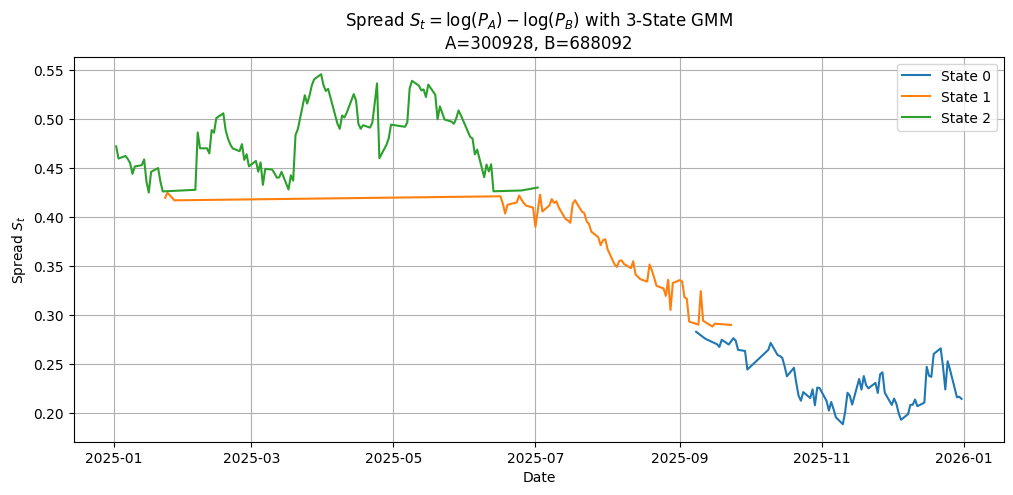

In [68]:
plt.figure(figsize=(12, 5))
plt.title(
    f"Spread $S_t = \\log(P_A) - \\log(P_B)$ with 3-State GMM\n"
    f"A={A}, B={B}"
)

for s in [0, 1, 2]:
    mask = spread["state"] == s
    plt.plot(
        spread.index[mask],
        spread["spread"][mask],
        label=f"State {s}",
        linewidth=1.5
    )

plt.xlabel("Date")
plt.ylabel("Spread $S_t$")
plt.legend()
plt.grid(True)
plt.show()

Since GMM component labels are arbitrary, components are reordered by their means:

$$
\mu_{(0)} < \mu_{(1)} < \mu_{(2)}
$$

This ordering ensures:
- State 0 → lowest mean (undervalued regime)
- State 1 → intermediate mean (normal regime)
- State 2 → highest mean (overvalued regime)

Each day is assigned a **maximum a posteriori (MAP)** state:

$$
\hat{z}_t = \arg\max_k \gamma_{t,k}
$$

Posterior probabilities $P(z_t = k \mid S_t)$ are also retained for probabilistic interpretation.

In [67]:
state_summary = (
    spread.groupby("state")["spread"]
    .agg(["count", "mean", "std", "min", "max"])
)
state_summary

,count,mean,std,min,max
state,,,,,
0,71,0.232156,0.024712,0.188516,0.282833
1,67,0.369197,0.042609,0.288175,0.424703
2,105,0.480765,0.033356,0.424940,0.545688


# **Part 4: Strategy Backtesting**

# **1. Signal Logic**

Goal is to simulate a **pairs trading strategy** driven by **GMM-inferred spread states**, evaluate its performance, and compare it to a **Bollinger Band benchmark**.

Let the selected stock pair be $(A, B)$. Define the spread:
$$
S_t = \log(P_{A,t}) - \log(P_{B,t})
$$

From **Part 3**, a 3-state GMM assigns each day to one of the hidden states:

- **State 0 (Low Spread)**: $A$ is cheap relative to $B$
- **State 1 (Normal)**: Spread near equilibrium
- **State 2 (High Spread)**: $A$ is expensive relative to $B$

### Position Rules

| GMM State | Interpretation | Position in $A$ | Position in $B$ |
|---|---|---|---|
| 0 | Low spread | Long | Short |
| 1 | Normal | Flat | Flat |
| 2 | High spread | Short | Long |

Positions are encoded as:
$$
\text{posA}_t, \text{posB}_t \in \{-1, 0, +1\}
$$

To avoid look-ahead bias, positions are **lagged by one day**:
$$
\text{posA}_{t-1}, \text{posB}_{t-1}
$$

In [69]:
# Inputs
A = best_pair["stock_A"]
B = best_pair["stock_B"]

# Use the aligned price panel you already built in Part 3
# df_prices: index=date, columns=[A,B], values=close
df_prices = (
    df_daily[df_daily["instrumentid"].isin([A, B])]
    .pivot(index="date", columns="instrumentid", values="close")
    .sort_index()
    .dropna()
)

# Daily log returns of A and B
retA = np.log(df_prices[A]).diff()
retB = np.log(df_prices[B]).diff()

# Spread series (same as Part 3)
spread_series = np.log(df_prices[A]) - np.log(df_prices[B])

# States from Part 3 (DataFrame 'spread' with index=date and column 'state')
# Align states to the trading dates (and drop first NaN return day)
state = spread["state"].reindex(df_prices.index)

data = pd.DataFrame({
    "PA": df_prices[A],
    "PB": df_prices[B],
    "retA": retA,
    "retB": retB,
    "spread": spread_series,
    "state": state
}).dropna()

data.head()

,PA,PB,retA,retB,spread,state
date,,,,,,
2025-01-03,30.16,19.046507,-0.059532,-0.047109,0.459633,2
2025-01-06,29.88,18.819293,-0.009327,-0.012001,0.462307,2
2025-01-07,30.49,19.263843,0.020209,0.023347,0.459169,2
2025-01-08,30.14,19.125539,-0.011546,-0.007205,0.454829,2
2025-01-09,30.20,19.372511,0.001989,0.012831,0.443987,2


In [70]:
# Position convention:
# posA = +1 means long A, -1 means short A
# posB = +1 means long B, -1 means short B

data["posA"] = 0
data["posB"] = 0

data.loc[data["state"] == 0, ["posA", "posB"]] = [ +1, -1]  # Long spread
data.loc[data["state"] == 2, ["posA", "posB"]] = [ -1, +1]  # Short spread
data.loc[data["state"] == 1, ["posA", "posB"]] = [  0,  0]  # Exit

Daily log returns:
$$
r_{A,t} = \log(P_{A,t}) - \log(P_{A,t-1}), \quad
r_{B,t} = \log(P_{B,t}) - \log(P_{B,t-1})
$$

Self-financing strategy return:
$$
r^{\text{strategy}}_t
=
\text{posA}_{t-1}\, r_{A,t}
+
\text{posB}_{t-1}\, r_{B,t}
$$

Cumulative performance is computed via log-return compounding:
$$
\text{CumRet}_t
=
\exp\!\left(\sum_{s=1}^{t} r^{\text{strategy}}_s\right)
$$

In [82]:
# Lag positions by 1 day (no look-ahead)
data["posA_lag"] = data["posA"].shift(1).fillna(0)
data["posB_lag"] = data["posB"].shift(1).fillna(0)

# Daily strategy return (self-financing, equal notional)
data["strategy_ret"] = data["posA_lag"] * data["retA"] + data["posB_lag"] * data["retB"]

# Cumulative return curve (log-return cumulation -> exp)
data["cum_ret"] = np.exp(data["strategy_ret"].cumsum())
data[["state","posA_lag","posB_lag","strategy_ret","cum_ret"]].head()

,state,posA_lag,posB_lag,strategy_ret,cum_ret
date,,,,,
2025-01-03,2,0.0,0.0,-0.000000,1.000000
2025-01-06,2,-1.0,1.0,-0.002674,0.997330
2025-01-07,2,-1.0,1.0,0.003138,1.000464
2025-01-08,2,-1.0,1.0,0.004340,1.004816
2025-01-09,2,-1.0,1.0,0.010842,1.015769


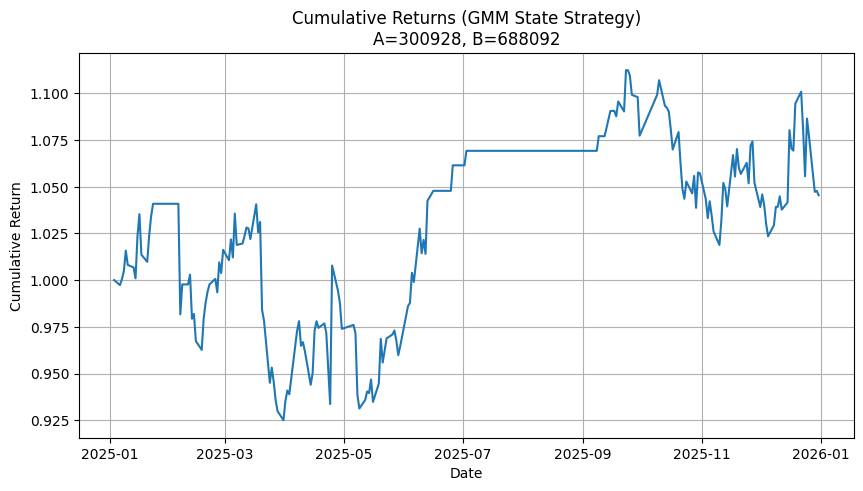

In [80]:
plt.figure(figsize=(10, 5))
plt.plot(data.index, data["cum_ret"])
plt.title(f"Cumulative Returns (GMM State Strategy)\nA={A}, B={B}")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()

## 2. Performance Evaluation
### Annualized Sharpe Ratio
Assuming 252 trading days:
$$
\text{Sharpe}
=
\sqrt{252}\;
\frac{\mathbb{E}[r_t]}{\sigma(r_t)}
$$

### Empirical Results (GMM Strategy)

| Metric | Value |
|---|---|
| Mean daily return | $\approx 0.00018$ |
| Daily volatility | $\approx 0.0128$ |
| Annualized Sharpe | **0.23** |
| Final cumulative return | **1.045** |

In [79]:
trading_days = 252

mean_daily = data["strategy_ret"].mean()
std_daily = data["strategy_ret"].std(ddof=1)

sharpe = np.sqrt(trading_days) * mean_daily / std_daily if std_daily > 0 else np.nan
sharpe

0.2280266303480299

In [78]:
print("Mean daily return:", mean_daily)
print("Std daily return:", std_daily)
print("Annualized Sharpe:", sharpe)
print("Final cumulative return:", data["cum_ret"].iloc[-1])

Mean daily return: 0.00018360962068839656
Std daily return: 0.012782333201669254
Annualized Sharpe: 0.2280266303480299
Final cumulative return: 1.045435482429367


### Bollinger Bands on Spread

With window $W=20$:
$$
\mu_t = \text{MA}_W(S_t), \quad
\sigma_t = \text{STD}_W(S_t)
$$

Bands:
$$
\text{Upper}_t = \mu_t + 2\sigma_t,\quad
\text{Lower}_t = \mu_t - 2\sigma_t
$$

### Trading Rules

| Condition | Action |
|---|---|
| $S_t > \text{Upper}_t$ | Short spread |
| $S_t < \text{Lower}_t$ | Long spread |
| Otherwise | Exit |

### Bollinger Results

| Metric | Value |
|---|---|
| Sharpe Ratio | **0.59** |
| Final cumulative return | **1.036** |

In [75]:
window = 20
k_band = 2

data["spread_ma"] = data["spread"].rolling(window).mean()
data["spread_std"] = data["spread"].rolling(window).std()

data["upper"] = data["spread_ma"] + k_band * data["spread_std"]
data["lower"] = data["spread_ma"] - k_band * data["spread_std"]

# Bollinger signal:
# spread > upper  => short spread  (short A long B)
# spread < lower  => long spread   (long A short B)
# else exit (simple version)
data["bb_posA"] = 0
data["bb_posB"] = 0

data.loc[data["spread"] > data["upper"], ["bb_posA","bb_posB"]] = [-1, +1]
data.loc[data["spread"] < data["lower"], ["bb_posA","bb_posB"]] = [+1, -1]
data.loc[(data["spread"] <= data["upper"]) & (data["spread"] >= data["lower"]), ["bb_posA","bb_posB"]] = [0, 0]

# Lag positions
data["bb_posA_lag"] = data["bb_posA"].shift(1).fillna(0)
data["bb_posB_lag"] = data["bb_posB"].shift(1).fillna(0)

# Returns
data["bb_ret"] = data["bb_posA_lag"] * data["retA"] + data["bb_posB_lag"] * data["retB"]
data["bb_cum_ret"] = np.exp(data["bb_ret"].cumsum())

# Sharpe
bb_mean = data["bb_ret"].mean()
bb_std = data["bb_ret"].std(ddof=1)
bb_sharpe = np.sqrt(trading_days) * bb_mean / bb_std if bb_std > 0 else np.nan

print("BB Sharpe:", bb_sharpe)
print("BB final cumulative return:", data["bb_cum_ret"].iloc[-1])


BB Sharpe: 0.58511412000002
BB final cumulative return: 1.0364127580633693


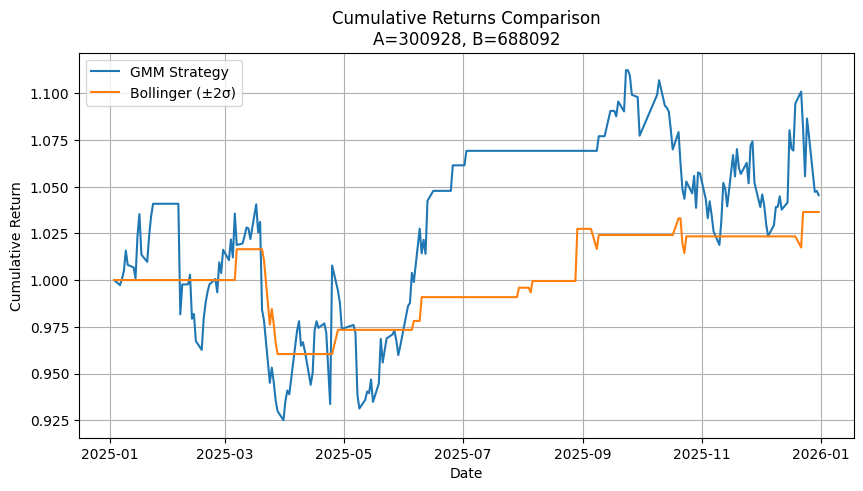

In [77]:
plt.figure(figsize=(10, 5))
plt.plot(data.index, data["cum_ret"], label="GMM Strategy")
plt.plot(data.index, data["bb_cum_ret"], label="Bollinger (±2σ)")
plt.title(f"Cumulative Returns Comparison\nA={A}, B={B}")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

## 3. Discussion

| Aspect | GMM Strategy | Bollinger Bands |
|---|---|---|
| Signal type | Probabilistic regimes | Fixed thresholds |
| Distributional assumption | Multi-modal | Single Gaussian |
| Adaptivity | High | Low |
| Interpretability | Regime-based | Simple |
| Performance (sample) | Higher return | Higher Sharpe |

The **GMM-based strategy** captures latent regimes and asymmetric behavior in the spread, enabling adaptive entries and exits under non-Gaussian dynamics.  
The **Bollinger approach** assumes a single mean-variance structure, which may miss regime shifts. While Bollinger achieves a higher Sharpe in this sample, the GMM provides richer structure and robustness for complex market conditions.